# PEA

PEA(PyPSA-EUR analysis) is a simple and fast tool for analyzing `network.nc`.

## Get Start

### 1. Create a pea instance

In [96]:
import pypsa
from pea import Pea, carriers as cs

n = pypsa.Network("../../results/smart/current/networks/base_s_27_3H_3H_2045.nc")
pea = Pea(n, config = {
  'zone': 'DE', # filter DE bus
})


INFO:pypsa.io:Imported network base_s_27_3H_3H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


### 2. view static data

In [97]:
pea.get(cs.onwind).df

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
DE0 0 onwind,DE0 0,PQ,,4705.898617,0.0,True,4705.898617,17500.564740,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,15463.759639
DE0 1 onwind,DE0 1,PQ,,5869.572607,0.0,True,5869.572607,30553.368011,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,21436.331084
DE0 2 onwind,DE0 2,PQ,,1496.669870,0.0,True,1496.669870,34030.033216,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,1496.671492
DE0 3 onwind,DE0 3,PQ,,10932.165370,0.0,True,10932.165370,30563.802759,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,30563.801962
DE0 4 onwind,DE0 4,PQ,,12952.011037,0.0,True,12952.011037,39956.150146,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,39956.149908
DE0 5 onwind,DE0 5,PQ,,5384.973073,0.0,True,5384.973073,19203.922460,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,19203.922211
DE0 6 onwind,DE0 6,PQ,,9829.220920,0.0,True,9829.220920,33462.990298,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,33462.990299
DE0 7 onwind,DE0 7,PQ,,2016.488506,0.0,True,2016.488506,22562.937775,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,18416.374069


Pass `cs.onwind` preset to restrict the carrier to `onwind`, use `df()` to view static data. Finally, display the onwind data for Germany. Just like `n.generators`

You can see all carriers preset in `/research/notebook/pea/carrier.py`. eg: `cs.offwind`, `cs.solar`, `cs.phs` and others. 

Some carrier presets contain multiple carriers. For example, `cs.offwind` includes `offwind-ac`, `offwind-dc`, `offwind-flat`:

In [98]:
pea.get(cs.offwind).df

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
DE0 3 offwind-float,DE0 3,PQ,,352.055570,0.0,True,352.055570,367.224094,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,352.055571
DE0 4 offwind-float,DE0 4,PQ,,67.953353,0.0,True,67.953353,251.412604,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,67.953376
DE0 6 offwind-float,DE0 6,PQ,,108.626628,0.0,True,108.626628,132.504020,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,108.626650
DE0 3 offwind-ac,DE0 3,PQ,,508.577718,0.0,True,508.577718,2462.602880,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2462.602574
DE0 4 offwind-ac,DE0 4,PQ,,491.431492,0.0,True,491.431492,6778.409194,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,491.431518
DE0 6 offwind-ac,DE0 6,PQ,,341.249579,0.0,True,341.249579,3480.737183,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,3480.737141
DE0 3 offwind-dc,DE0 3,PQ,,5402.419722,0.0,True,5402.419722,63474.110540,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,63474.109697
DE0 4 offwind-dc,DE0 4,PQ,,122.844614,0.0,True,122.844614,821.371074,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,821.370705
DE0 6 offwind-dc,DE0 6,PQ,,159.841325,0.0,True,159.841325,759.040299,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,759.040067


### 3. View time series data

In [99]:
pea.get(cs.onwind).t('p')

Generator,DE0 0 onwind,DE0 1 onwind,DE0 2 onwind,DE0 3 onwind,DE0 4 onwind,DE0 5 onwind,DE0 6 onwind,DE0 7 onwind
snapshot,,,,,,,,
2019-01-01 00:00:00,1037.642372,4771.941889,157.720331,19722.080286,31885.437288,5480.972590,18444.269380,945.201274
2019-01-01 03:00:00,2311.192700,8270.655473,283.990008,24294.741205,36156.785076,8740.928456,25948.248987,2000.079067
2019-01-01 06:00:00,4067.644857,11626.444132,462.250730,25240.542529,37668.231874,10875.030789,30227.209878,3298.833644
2019-01-01 09:00:00,5223.430541,12605.346066,600.772615,22790.365325,37202.368208,9801.524891,26504.373410,5057.615963
2019-01-01 12:00:00,6147.984894,14862.230326,900.585508,25347.298298,37583.938681,10072.048851,29609.266496,6480.723350
...,...,...,...,...,...,...,...,...
2019-12-31 09:00:00,0.000000,2778.680825,149.957046,4704.818349,21502.531089,0.000000,18410.836107,1242.857584
2019-12-31 12:00:00,0.000000,1445.653295,79.570523,3160.200858,15189.463589,0.000000,16264.286989,0.000000
2019-12-31 15:00:00,0.000000,1378.191803,85.770594,2446.542873,12089.910966,0.000000,13205.412606,0.000000


 use `t("p")` to view time series data, just like `n.generators_t.p`. You can also view other time series data, eg:  `t('status')`,`t('p1')` (for link or line), `t('e')`(for store).

### 4. calculate metrics 

In [100]:
onwind = pea.get(cs.onwind)
print('Total CAPEX: ', onwind.capex())
print('Total optimized power: ', onwind.p_nom_opt())
print('Total total electricity generation', onwind.energy())

Total CAPEX:  871650.8362355612
Total optimized power:  180000.0006627475
Total total electricity generation 117975246.72638462


For the Link and line components, when calculating energy, it is necessary to pass in `p0`, `p1`, `p2` to specify which node's values to record.

In [101]:
gasPower = pea.get(cs.gasPower) # gasPower is OCGT and  OCCT
print('Total CAPEX: ', onwind.capex())
print('Total optimized power: ', gasPower.p_nom_opt())
print('Total total electricity generation', gasPower.energy('p1'))


Total CAPEX:  871650.8362355612
Total optimized power:  32144.22315250757
Total total electricity generation 299664.45413967443


### 5. calculate import or export

In [102]:
pea.get(cs.power, type='export').exportP()

,relation/16213216-525-DC,relation/3918230-450-DC,relation/2505320-400-DC-reversed,relation/8193755-320-DC-reversed,18,27,29,30,31,32,relation/16213216-525-DC,relation/3918230-450-DC,relation/2505320-400-DC-reversed,relation/8193755-320-DC-reversed,18,27,29,30,31,32
snapshot,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.002789,0.003759,0.004086,687.619978,209.014120,0.000000,0.000000,873.184609,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,408.525040,8138.663657,0.000000,9400.648537,1694.319343
2019-01-01 03:00:00,1399.999502,599.999696,0.278657,0.038792,2068.759149,0.000000,0.000000,1390.572579,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,44.221525,7420.507081,0.000000,7959.202995,1066.229584
2019-01-01 06:00:00,1399.998385,599.998582,0.075011,268.242744,3594.446302,96.836384,0.000000,1666.415562,0.0,346.459188,0.0,0.0,0.0,0.0,0.000000,0.000000,1129.050354,0.000000,7401.079714,0.000000
2019-01-01 09:00:00,1399.998522,599.998718,0.176562,0.013344,3814.975740,166.211778,5908.819082,1270.984098,0.0,427.783908,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,7126.581101,0.000000
2019-01-01 12:00:00,1399.999533,599.997408,0.021789,111.815780,4111.639463,632.146555,9730.991956,1806.424609,0.0,427.784002,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5283.009598,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 09:00:00,0.031248,0.003849,0.004416,2068.408163,3942.896601,852.009802,0.000000,1526.035554,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,964.031457,0.000000,4464.705040,1219.844032
2019-12-31 12:00:00,0.000943,0.000941,0.000969,2068.234229,1875.363204,615.046361,0.000000,1228.367085,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,4751.233541,0.000000,5174.502694,2681.685103
2019-12-31 15:00:00,0.000720,0.000723,0.000884,0.003667,0.000000,1098.094913,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1017.609414,0.000000,4751.213160,771.843305,3548.810091,2446.872598


Displayed the power time series data of link and line exports from Germany. Reverse lines have been considered, and the values are taken as absolute values. 

`cs.power` refers to AC and DC lines. Use `cs.h2Pipeline` to calculate the import and export volumes of hydrogen, and use `cs.gasPipeline` to calculate the import and export volumes of gas.

An import time graph can be plotted.

<Axes: xlabel='snapshot'>

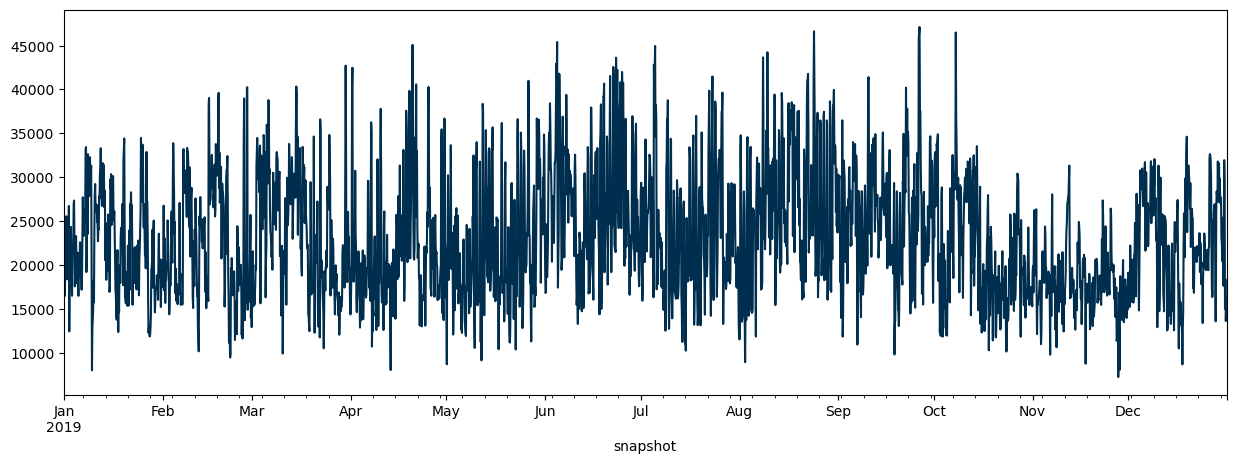

In [103]:
pea.get(cs.power, type='export').exportP().sum(axis=1).plot(figsize=(15,5), color=cs.colors[0])

Calculate total imported electricity:

In [104]:
pea.get(cs.power, type='import').importP().sum(axis=1).sum()

54160495.72385956

### 6. make Beautiful Diagram

This is an example illustrating the installed capacity of different devices. Except, use readable names and change colors.

<Axes: >

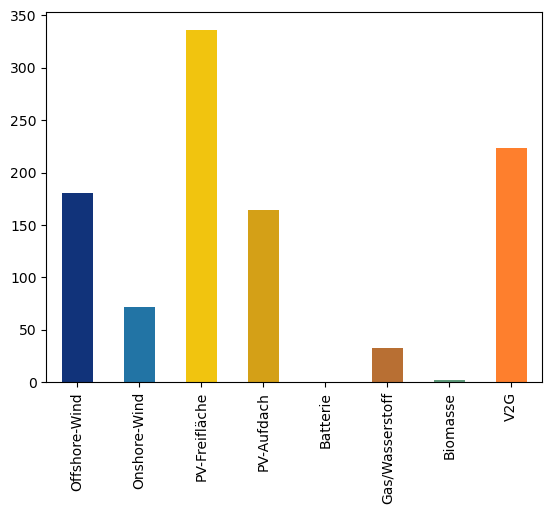

In [105]:
import pandas as pd

s = pd.Series()

# Use carrier presets to calculate the optimized capacity for different types of carriers.
for carrier in ['onwind', 'offwind', 'solar', 'solarRooftop', 'batteryDischarger', 'gasH2Power', 'biomassCHP', 'v2g']:
    s[carrier] = pea.get(getattr(cs,carrier)).df['p_nom_opt'].sum()

# Use readable name.
s = s.rename(index=cs.mapName)

# WM -> TW
s= s / 1e3

# Use color presets.
colorMap =  [cs.mapNameColor[i] for i in s.index]

# plot bar
s.plot(kind="bar", color=colorMap)
